In [1]:
import sys, os
sys.path.append(os.path.abspath("src"))
#from src.utils.utils_import import *

import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import os, spacy, requests
from io import StringIO
from datetime import timedelta

import matplotlib.pyplot as plt


In [2]:
def save_to_csv(df, path): 
    '''
    Save DataFrame to CSV file.
    Args:
        df (pd.DataFrame): DataFrame to save.
        path (str): Path to save the CSV file.
    '''
    
    df.to_csv(path, index=False)
    
    
# =========================
# Data loaders
# =========================
def get_image_data(): 
    '''
    Scrape dataset from New Yorker caption contest website, and load and clean image metadata.
    Returns:
        pd.DataFrame: Cleaned DataFrame with image metadata.
    '''
    
    data_folder = './data/newyorker_caption_contest/'
    df = pd.read_json(data_folder + 'contests.json')
    metadata = df['metadata'].apply(pd.Series)
    df = pd.concat([df.drop(columns=['metadata']), metadata], axis=1)

    #scrape data from caption contest website
    url = "https://nextml.github.io/caption-contest-data/"
    soup = BeautifulSoup(requests.get(url).content, 'html.parser')

    df_scrape = pd.read_html(StringIO(str(soup.find('table'))))[0]


    #clean df_scrape columns
    df_scrape['Contest Dashboard'] = df_scrape['Contest Dashboard'].str.replace(' Dashboard', '').str.strip()
    df_scrape.rename(columns={'Finalists Announced (date of issue)': 'date'}, inplace=True)
    df_scrape['date'] = df_scrape['date'].str.replace(' (estimated)', '').str.strip()
    df_scrape.drop(columns=['Cartoon'], inplace=True)
    df_scrape = df_scrape.iloc[::-1].reset_index(drop=True)

    df_scrape['date'] = pd.to_datetime(df_scrape['date'], errors='coerce')
    
    # Assume contest happens each week and fill missing dates
    for i in range(1, len(df_scrape)):
        if pd.isna(df_scrape.loc[i, 'date']):
            df_scrape.loc[i, 'date'] = df_scrape.loc[i - 1, 'date'] + timedelta(days=7)

    for i in range(len(df_scrape)-2, -1, -1):
        if pd.isna(df_scrape.loc[i, 'date']):
            df_scrape.loc[i, 'date'] = df_scrape.loc[i+1, 'date'] - timedelta(days=7)

    df_scrape['Contest Dashboard'] = df_scrape['Contest Dashboard'].astype(int)
    df_complete = pd.merge(df, df_scrape, left_on='contest_id', right_on='Contest Dashboard')

    df_complete.drop(columns=['image'], inplace=True)
    df_complete.drop(columns=['data'], inplace=True)
    df_complete.drop(columns=['Contest Dashboard'], inplace=True)
    df_complete.drop(columns=['num_votes'], inplace=True) #better to keep Number of Votes from the official website

    return df_complete


def get_caption_dataset(df_image):
    '''
    Load and clean New Yorker caption contest captions.
    Args:
        df_image (pd.DataFrame): DataFrame with image metadata and website data.
    Returns:
        pd.DataFrame: Cleaned DataFrame with captions and associated metadata.
    '''
    
    path = "./data/newyorker_caption_contest/data/"
    files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and i.endswith('.csv')]

    df = pd.DataFrame()

    data_frames = []
    for file in files:
        
        data = pd.read_csv(file, sep=',', encoding='latin-1')
        file_number_csv =  os.path.split(file)[-1]
        file_number = int(file_number_csv.replace('.csv', ''))
        data['contest_id'] = file_number #add a column with the contest id 
        # starting from 660 the rank is no longer shown, but by comparing it with https://nextml.github.io/caption-contest-data/dashboards/883.html
        # we can assume that the order is the rank 
        if file_number >= 660: 
            data.insert(0, 'rank', np.arange(0, len(data)))
        data_frames.append(data)

    df = pd.concat(data_frames, ignore_index=True)

    # get rid of empty captions, get rid of broken captions 
    # find not complete parts   e.g 63867
    df_cleaned = df[df['caption'].notnull()] 
    df_cleaned = df_cleaned[~df_cleaned['caption'].str.contains(r'[\r\n]', regex=True)]

    df_cleaned = df_cleaned[~df_cleaned['caption'].isnull() == True]

    #join both dataframes on contest_id
    merged_df = pd.merge(df_image[["contest_id", "date"]], df_cleaned, on="contest_id", how="inner")
    
    return merged_df

In [3]:
df_image = get_image_data()
df_caption = get_caption_dataset(df_image)

# Introduction


In [4]:
df_image.describe()

,contest_id,num_captions,date,Number of votes
count,384.000000,240.000000,384,3.840000e+02
mean,703.385417,6181.308333,2020-01-09 13:22:30,7.602295e+05
min,510.000000,2919.000000,2016-03-07 00:00:00,3.117300e+04
25%,607.750000,4764.250000,2018-03-17 06:00:00,5.660992e+05
50%,703.500000,5784.000000,2020-01-16 12:00:00,7.614170e+05
75%,799.250000,7326.250000,2021-11-16 18:00:00,9.383070e+05
max,895.000000,15329.000000,2023-09-18 00:00:00,2.249813e+06
std,111.182335,1978.687145,NaN,3.438207e+05


In [ ]:
print(f"total votes: {df_caption['votes'].sum()}")

np.int64(287757060)

In [7]:
df_caption.describe().apply(lambda s: s.apply('{0:.0f}'.format))

,contest_id,date,rank,mean,precision,votes,not_funny,somewhat_funny,funny
count,2263048,2263048,2263048,2263048,2263048,2263048,2263048,2263048,2263048
mean,706,.0f,3238,1,inf,127,92,25,10
min,510,.0f,0,1,0,1,0,0,0
25%,615,.0f,1485,1,0,60,51,6,1
50%,713,.0f,2984,1,0,84,69,12,2
75%,791,.0f,4604,1,0,123,97,21,6
max,895,.0f,15328,3,inf,25891,7740,9721,15232
std,106,nan,2184,0,nan,353,155,122,91


# General analysis


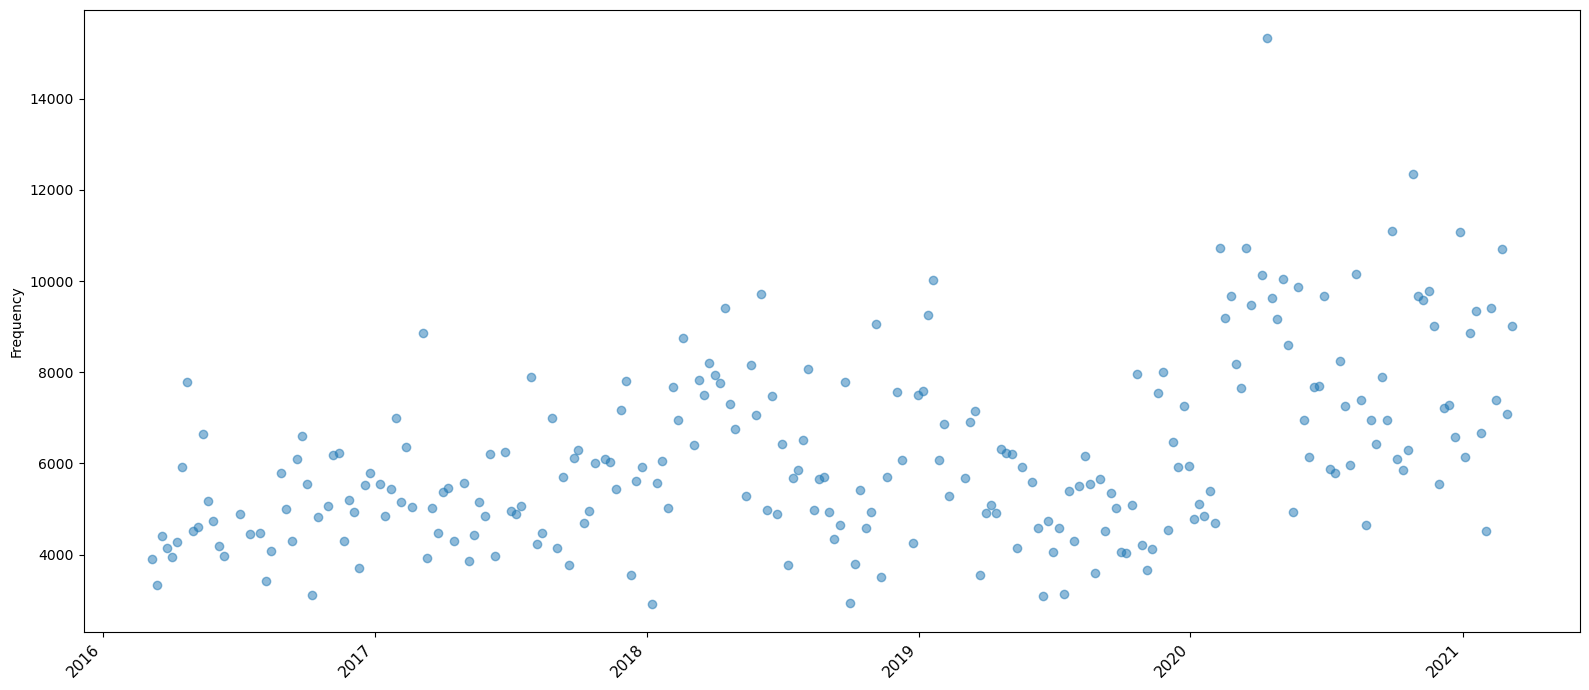

In [ ]:
plt.figure(figsize=(16, 7))
#make histogram
plt.scatter(df_image['date'], y=df_image.num_captions, alpha=0.5)
#plt.scatter(df_image['date'], df_image.num_captions, alpha=0.5)

plt.xticks(rotation=45, fontsize=11, ha="right")

plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
df_export_frequency_captions = df_image[['date', 'num_captions']].copy()
df_export_frequency_captions['date'] = df_export_frequency_captions['date'].dt.strftime('%d-%m-%Y')
df_export_frequency_captions.dropna(subset=['num_captions'], inplace=True)
#df_export_frequency_captions = df_export_frequency_captions[df_export_frequency_captions['num_captions'].notna()]
df_export_frequency_captions



,date,num_captions
0,07-03-2016,3905.0
1,14-03-2016,3325.0
2,21-03-2016,4399.0
3,27-03-2016,4141.0
4,03-04-2016,3951.0
...,...,...
247,08-02-2021,9411.0
248,15-02-2021,7393.0
249,22-02-2021,10712.0
250,01-03-2021,7076.0


In [17]:
df_caption = df_caption.merge(df_image[['contest_id', 'date']], on='contest_id', how='left')
df_caption

,contest_id,date_x,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,date_y
0,510,2016-03-07,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,2016-03-07
1,510,2016-03-07,1,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5,2016-03-07
2,510,2016-03-07,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,2016-03-07
3,510,2016-03-07,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,2016-03-07
4,510,2016-03-07,4,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6,2016-03-07
...,...,...,...,...,...,...,...,...,...,...,...
2263043,895,2023-09-18,4953,Looks like we took a wrong turn at the Hubble ...,1.023256,0.016347,86,84,2,0,2023-09-18
2263044,895,2023-09-18,4954,Post-modern just doesn't do it for me.,1.022222,0.015625,90,88,2,0,2023-09-18
2263045,895,2023-09-18,4955,How was I supposed to know they covered themse...,1.020833,0.014654,96,94,2,0,2023-09-18
2263046,895,2023-09-18,4956,"No, they wanted us to teleport the giveaway ca...",1.020619,0.020619,97,96,0,1,2023-09-18


In [18]:
summary_votes = (
    df_caption
    .groupby('contest_id', as_index=False)
    .agg(
        date = ('date_x', 'first'),
        total_votes=('votes', 'sum'),
        total_captions=('contest_id', 'count'),
        total_funny=('funny', 'sum'),
        total_somewhat_funny=('somewhat_funny', 'sum'),
        total_not_funny=('not_funny', 'sum')
    )
)
summary_votes['date'] = summary_votes['date'].dt.strftime('%d-%m-%Y')

summary_votes

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
0,510,07-03-2016,41185,3905,709,3438,37038
1,511,14-03-2016,28205,3325,599,2950,24656
2,512,21-03-2016,21574,4399,609,2416,18549
3,513,27-03-2016,16894,4141,657,2424,13813
4,514,03-04-2016,95790,3951,7639,22267,65884
...,...,...,...,...,...,...,...
379,891,21-08-2023,928735,5158,50679,165114,712942
380,892,28-08-2023,788251,5188,50492,141107,596652
381,893,04-09-2023,1085745,5513,83768,215129,786848
382,894,11-09-2023,878676,6157,44343,128594,705740


In [19]:
top_three = summary_votes.nlargest(3, 'total_captions')
print(top_three)

     contest_id        date  total_votes  total_captions  total_funny  \
204         716  13-04-2020       259088           15147        11781   
232         744  26-10-2020      1091840           12148        59903   
228         740  28-09-2020      1006065           10934        86596   

     total_somewhat_funny  total_not_funny  
204                 39237           208070  
232                196543           835395  
228                230840           688596  


In [ ]:
print(f" max captions:  {summary_votes[summary_votes['total_captions'] == summary_votes['total_captions'].max()]}")

 max      contest_id        date  total_votes  total_captions  total_funny  \
204         716  13-04-2020       259088           15147        11781   

     total_somewhat_funny  total_not_funny  
204                 39237           208070  


In [21]:
summary_votes.describe().apply(lambda s: s.apply('{0:.0f}'.format))

,contest_id,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
count,384,384,384,384,384,384
mean,703,749367,5893,59962,147377,541996
std,111,341770,1751,39882,81207,240120
min,510,16894,1052,4,1964,13813
25%,608,558457,4645,33443,93163,423958
50%,704,751493,5588,53629,145615,548008
75%,799,928229,6825,78173,194649,662273
max,895,2210972,15147,263727,432364,1703970


In [22]:
summary_votes[summary_votes['total_votes'] == summary_votes['total_votes'].max()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
139,651,14-01-2019,2210972,9089,125636,381366,1703970


In [23]:
summary_votes[summary_votes['total_votes'] == summary_votes['total_votes'].min()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
3,513,27-03-2016,16894,4141,657,2424,13813


In [24]:
summary_votes[summary_votes['total_funny'] == summary_votes['total_funny'].max()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
206,718,27-04-2020,1906570,9023,263727,427402,1215439


In [26]:
df_image.rename(columns={"Number of votes": "number_of_votes"})


,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,number_of_votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198
...,...,...,...,...,...,...,...,...,...,...,...
379,891,NaN,NaN,NaN,NaN,NaN,NaN,"“Sorry, only the catcher works from home.”",NaN,2023-08-21,928856
380,892,NaN,NaN,NaN,NaN,NaN,NaN,"“Yes, it's called Thesaurus, but you're not re...",NaN,2023-08-28,788251
381,893,NaN,NaN,NaN,NaN,NaN,NaN,“The seller isn't willing to come down.”,NaN,2023-09-04,1085745
382,894,NaN,NaN,NaN,NaN,NaN,NaN,“See how the nose seems to follow you?”,NaN,2023-09-11,878676


In [27]:
#average number of votes
print(f"average number of votes {df_image['number_of_votes'].mean()}")
#average number of captions
print(f"average number of captions: {df_image['num_captions'].mean()}")
print(f"average number of images: {df_image['contest_id'].count()}")

KeyError: 'number_of_votes'

In [ ]:
print(f"number of votes {df_image['number_of_votes'].sum()}")
#average number of captions
print(f"number of captions: {df_image['num_captions'].sum()}")